In [1]:
!pip install -q datasets==2.21.0
!pip install -q --upgrade datasets transformers av evaluate jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 27.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 138.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 124.7 MB/s eta 0:00:00


In [2]:
import torch
import re
import json
import numpy as np
import evaluate
from datasets import load_dataset, Audio
from transformers import Wav2Vec2CTCTokenizer, Wav2Vec2FeatureExtractor, Wav2Vec2Processor

# Task 2
import scipy.signal as sps
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt
import os
import torch
import matplotlib.pyplot as plt
import gc

import pandas as pd
from datasets import Dataset, DatasetDict
from transformers import TrainingArguments, Trainer

# Завдання 1

In [3]:
print("    завантаження датасету    ")
dataset = load_dataset("speech-uk/opentts-mykyta", split="train")


    завантаження датасету    


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/195M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6436 [00:00<?, ? examples/s]

In [4]:
dataset

Dataset({
    features: ['audio', 'duration', 'transcription', 'transcription_stressed'],
    num_rows: 6436
})

In [5]:
import random
import IPython.display as ipd

idx = random.randint(0, len(dataset) - 1)
sample = dataset[idx]

print(f"Індекс випадкового елементу датасету: {idx}")
print(sample["duration"])
print(sample["transcription"])

ipd.Audio(sample["audio"]["array"], rate=sample["audio"]["sampling_rate"])

Індекс випадкового елементу датасету: 1960
3.0
Чи знали ви про це?


Серед переглянутих семплів спостерігається, що аудіо є літературним читанням, повільне, з виразною інтонацією та чітко-вираженими паузами

In [6]:
print(np.mean(dataset["duration"]))
print(np.std(dataset["duration"]))
print(np.min(dataset["duration"]))
print(np.max(dataset["duration"]))

5.076089807333748
1.5152019165960877
1.9
11.5


In [7]:
sample_rates = set()

for sample in dataset:
    sample_rates.add(sample["audio"]["sampling_rate"])

print("Наявні sample rates:")
for sr in sorted(sample_rates):
    print(sr)

Наявні sample rates:
48000


In [8]:
channels = set()

for sample in dataset:
    audio_array = sample["audio"]["array"]

    if len(audio_array.shape) == 1:
        channels.add("mono")
    else:
        channels.add(f"{audio_array.shape[1]} channels")

print("Кількість каналів:")
for ch in sorted(channels):
    print(ch)

Кількість каналів:
mono


Тут ми завантажуємо датасет. 10% з нього виділяємо на валідацію. Нормалізуємо аудіо, приводимо до спільного виду: кастимо будь-яку чистоту до 16кГц, очищуємо текст від знаків пунктуації та зводимо у lower case. Проганяємо через цю нормалізацію кожен рядок нашого датасету

In [9]:
print("    завантаження датасету    ")
dataset = load_dataset("speech-uk/opentts-mykyta", split="train")
dataset = dataset.train_test_split(test_size=0.1, seed=42)

dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))
chars_to_remove_regex = r'[,?.!\-;:"“”—_]'
def remove_special_characters(batch):
    batch["transcription"] = batch["transcription"].lower()
    batch["transcription"] = re.sub(chars_to_remove_regex, '', batch["transcription"])
    return batch
dataset = dataset.map(remove_special_characters)
print("      готово     ")

    завантаження датасету    


Map:   0%|          | 0/5792 [00:00<?, ? examples/s]

Map:   0%|          | 0/644 [00:00<?, ? examples/s]

      готово     


Генеруємо словник, який буде виглядати як алфавіт. Алфавіт, бо Wav2Vec працює на рівні символів, тобто вона розпізнає самі звуки **літер**.


Символи з тестоої та тренувальної вибірки об'єднюємо, аби жоден не був пропущений. Кожному символу присвоємо свій індекс.


Використовуємо 2 токени: **blank** - для позначення пауз між звуками, та **unk** - для позначення символів, які модель раніше не бачила

Також замінюємо пробіли на зрозуміий для моделі символ |

In [10]:
def extract_all_chars(batch):
    all_text = " ".join(batch["transcription"])
    vocab = list(set(all_text))
    return {"vocab": [vocab], "all_text": [all_text]}

vocab_train = dataset["train"].map(extract_all_chars, batched=True, batch_size=-1, keep_in_memory=True, remove_columns=dataset["train"].column_names)
vocab_val = dataset["test"].map(extract_all_chars, batched=True, batch_size=-1, keep_in_memory=True, remove_columns=dataset["test"].column_names)

vocab_list = list(set(vocab_train["vocab"][0]) | set(vocab_val["vocab"][0]))
vocab_dict = {v: k for k, v in enumerate(sorted(vocab_list))}
vocab_dict = {k: v+2 for k, v in vocab_dict.items()}
vocab_dict["<blank>"] = 0
vocab_dict["<unk>"] = 1
if " " in vocab_dict:
    vocab_dict["|"] = vocab_dict[" "]
    del vocab_dict[" "]

with open('vocab.json', 'w', encoding='utf-8') as vocab_file:
    json.dump(vocab_dict, vocab_file, ensure_ascii=False)

Map:   0%|          | 0/5792 [00:00<?, ? examples/s]

Map:   0%|          | 0/644 [00:00<?, ? examples/s]

Перетворюємо звук на масиви чисел через FetureExtractor та тексту на індекси через токанайзер.


На початку ми нормалізуємо амплітуду звуку: тобто моделі має бути все одно, чи голосно/тихо був зроблений запис. Ну і працюємо з аудіо як з одновимірним масивом.

In [11]:
tokenizer = Wav2Vec2CTCTokenizer("./vocab.json", unk_token="<unk>", pad_token="<blank>", word_delimiter_token="|")
feature_extractor = Wav2Vec2FeatureExtractor(feature_size=1, sampling_rate=16000, padding_value=0.0, do_normalize=True, return_attention_mask=False)
processor = Wav2Vec2Processor(feature_extractor=feature_extractor, tokenizer=tokenizer)

def prepare_dataset(batch):
    audio = batch["audio"]
    batch["input_values"] = processor(audio["array"], sampling_rate=audio["sampling_rate"]).input_values[0]
    batch["labels"] = processor(text=batch["transcription"]).input_ids
    return batch

dataset_prepared = dataset.map(prepare_dataset, remove_columns=dataset["train"].column_names)

print("дані готові, ура ура")

Map:   0%|          | 0/5792 [00:00<?, ? examples/s]

Map:   0%|          | 0/644 [00:00<?, ? examples/s]

дані готові, ура ура


Тут ми створили свій клас моделі: ми взяли вже готову SSL модель та додали вже свій класифікатор. Модель в ході своєї роботи використовує результати **всіх** своїх внутрішніх шарів.

Метод **forward** працює настпуним чином: спочатку ми проганяємо звук через Wav2Vec, далі ми дістаємо hidden states з усіх шарів мережі. Обираємо фічі лише з того шару, який був вказаний при ініціалізації (-2 це предостанній шар). Далі пропускаємо ці дані через лінійний хед і вже отримуємо предікшини моделі

In [12]:
import torch
import torch.nn as nn
from transformers import Wav2Vec2Model, Wav2Vec2Config

class CustomSSLForCTC(nn.Module):
    def __init__(self, model_name, vocab_size, layer_index=-1):
        super().__init__()
        self.layer_index = layer_index
        config = Wav2Vec2Config.from_pretrained(model_name)
        config.output_hidden_states = True
        self.wav2vec2 = Wav2Vec2Model.from_pretrained(model_name, config=config)
        self.wav2vec2.feature_extractor._freeze_parameters()
        hidden_size = config.hidden_size
        self.lm_head = nn.Linear(hidden_size, vocab_size)

    def forward(self, input_values, attention_mask=None, labels=None):
        outputs = self.wav2vec2(
            input_values=input_values,
            attention_mask=attention_mask
        )

        hidden_states = outputs.hidden_states
        selected_features = hidden_states[self.layer_index]
        logits = self.lm_head(selected_features)

        return logits

print("ініціалізація")
vocab_size = len(vocab_dict)
model = CustomSSLForCTC(
    model_name="facebook/wav2vec2-base",
    vocab_size=vocab_size,
    layer_index=-2
)

print(f"слой: {model.layer_index}, розмір голови: {vocab_size} класів")

ініціалізація


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


слой: -2, розмір голови: 37 класів


Оцінимо якість того, як ми розпізнаватимо мову. Для цього тут буде використовуватися **word error rate** та **character error rate**. WER буде рахувати відсоток слів, які модель вгадала неправильно. CER працює +- за таким ж самим принципом, але на рівні букв. Тобто, CER більше для точності

In [13]:
!pip install evaluate jiwer

import numpy as np
import evaluate

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

def compute_metrics(pred):
    pred_logits = pred.predictions
    pred_ids = np.argmax(pred_logits, axis=-1)
    pred.label_ids[pred.label_ids == -100] = processor.tokenizer.pad_token_id
    pred_str = processor.batch_decode(pred_ids)
    label_str = processor.batch_decode(pred.label_ids, group_tokens=False)
    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    cer = cer_metric.compute(predictions=pred_str, references=label_str)

    return {"wer": wer, "cer": cer}

print("готово")

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

готово


Спочатку ми налаштовуємо wer та cer, аби під час навчання модель могла сама перевіряти, скільки помилок вона робить у словах та літерах. Потім ми створюємо DataCollator, який вирівнює аудіозаписи різної довжини в однакові батчі та позначає порожні місця числом -100, аби модель модель їх ігнорувала (вирівнюємо за самим довгим аудіозаписом)

Далі ми беремо XLS-R-53, заморожуємо її нижні шари та задаємо параметри навчання. У самому кінці Trainer об'єднує модель, дані та налаштування, і запускає тренування

In [14]:
from transformers import TrainingArguments, Trainer, Wav2Vec2ForCTC
import evaluate
import numpy as np
import torch
from dataclasses import dataclass
from typing import Dict, List, Union

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

def compute_metrics(pred):
    pred_logits = pred.predictions
    pred_ids = np.argmax(pred_logits, axis=-1)
    pred.label_ids[pred.label_ids == -100] = processor.tokenizer.pad_token_id
    pred_str = processor.batch_decode(pred_ids)
    label_str = processor.batch_decode(pred.label_ids, group_tokens=False)
    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    cer = cer_metric.compute(predictions=pred_str, references=label_str)
    return {"wer": wer, "cer": cer}

@dataclass
class DataCollatorCTCWithPadding:
    processor: any
    padding: Union[bool, str] = True

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_values": feature["input_values"]} for feature in features]
        label_features = [{"input_ids": feature["labels"]} for feature in features]

        batch = self.processor.pad(input_features, padding=self.padding, return_tensors="pt")
        labels_batch = self.processor.tokenizer.pad(label_features, padding=self.padding, return_tensors="pt")
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        batch["labels"] = labels
        return batch

data_collator = DataCollatorCTCWithPadding(processor=processor, padding=True)

model = Wav2Vec2ForCTC.from_pretrained(
    "facebook/wav2vec2-large-xlsr-53",
    attention_dropout=0.1,
    hidden_dropout=0.1,
    feat_proj_dropout=0.0,
    mask_time_prob=0.05,
    layerdrop=0.1,
    ctc_loss_reduction="mean",
    pad_token_id=processor.tokenizer.pad_token_id,
    vocab_size=len(processor.tokenizer)
)
model.freeze_feature_encoder()

training_args = TrainingArguments(
    output_dir="./wav2vec2-custom-uk",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="steps",
    num_train_epochs=3,
    fp16=True,
    save_steps=200,
    eval_steps=200,
    logging_steps=50,
    learning_rate=3e-4,
    weight_decay=0.005,
    warmup_steps=100,
    save_total_limit=2,
    remove_unused_columns=False
)

trainer = Trainer(
    model=model,
    data_collator=data_collator,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=dataset_prepared["train"],
    eval_dataset=dataset_prepared["test"],
)

trainer.train()

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-large-xlsr-53
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
lm_head.bias                 | MISSING    | 
lm_head.weight               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2172, training_loss=1.7378905256369714, metrics={'train_runtime': 628.5335, 'train_samples_per_second': 27.645, 'train_steps_per_second': 3.456, 'total_flos': 3.9065252119986365e+18, 'train_loss': 1.7378905256369714, 'epoch': 3.0})

видно, що CER впав з 1.0 до 0.03, значить можемо зробити висновок, що модель навчилась розпізнавати українську мову

 ### Порівняння оригінального тексту та розпізнаного

 Ми беремо якийсь приклад з тестової вибірки, який модель точно не бачила під час навчання. Переконуємось, що звук у правильному форматі (для тензора пайторча). У нас модель знаходиться на gpu, тому звук переносимо туди ж, викоючаємо рахування градієнтів.


 Проходимось по таблиці з ймовірностями для кожної літери, та обираємо той варіант, де ймовірність найвища. В результаті отримуємо послідовність номерів для літер. Далі ми перетворюємо ці номери назад у букви

In [15]:
import torch
from datasets import load_dataset, Audio

sample = dataset_prepared["test"][15]
inputs = processor(sample["input_values"], return_tensors="pt", sampling_rate=16000)
inputs = {k: v.to("cuda") for k, v in inputs.items()}
model.eval()
with torch.no_grad():
    logits = model(inputs["input_values"]).logits

predicted_ids = torch.argmax(logits, dim=-1)
transcription = processor.batch_decode(predicted_ids)[0]
print(f"оригінальний: {processor.decode(sample['labels'])}")
print(f"розпізнаний:  {transcription}")

import IPython.display as ipd
ipd.Audio(data=dataset["test"][15]["audio"]["array"], autoplay=False, rate=16000)

оригінальний: голос дзвоника це був наш умовлений сигнал
розпізнаний:  голосд звоника це був наш умовлений сигн


In [16]:
from datasets import load_dataset, Audio
import re

cv_test = load_dataset('Yehor/cv10-uk-testset-clean', split="train")
cv_test = cv_test.cast_column("audio", Audio(sampling_rate=16000))

def prepare_cv(batch):
    text = batch["transcription"].lower()
    text = re.sub(chars_to_remove_regex, '', text)
    batch["input_values"] = processor(batch["audio"]["array"], sampling_rate=16000).input_values[0]
    batch["labels"] = processor(text=text).input_ids
    return batch

cv_test_prepared = cv_test.select(range(100)).map(prepare_cv)
callbacks_to_remove = [
    cb for cb in trainer.callback_handler.callbacks
    if 'Notebook' in cb.__class__.__name__ or 'Progress' in cb.__class__.__name__
]
for cb in callbacks_to_remove:
    trainer.remove_callback(cb)
cv_results = trainer.evaluate(cv_test_prepared)

print(f"wer: {cv_results['eval_wer']:.4f}")
print(f"cer: {cv_results['eval_cer']:.4f}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/228M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/231M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3204 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

wer: 0.8021
cer: 0.2681


In [17]:
import gc
import torch
from transformers import AutoModelForCTC, TrainingArguments, Trainer

try:
    del hubert_model
    del hubert_trainer
    gc.collect()
    torch.cuda.empty_cache()
except:
    pass


base_model = AutoModelForCTC.from_pretrained(
    "facebook/wav2vec2-base",
    attention_dropout=0.1,
    hidden_dropout=0.1,
    feat_proj_dropout=0.0,
    mask_time_prob=0.05,
    layerdrop=0.1,
    ctc_loss_reduction="mean",
    pad_token_id=processor.tokenizer.pad_token_id,
    vocab_size=len(processor.tokenizer)
)
base_model.freeze_feature_encoder()

base_args = TrainingArguments(
    output_dir="./wav2vec2-base-custom-uk",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="steps",
    num_train_epochs=3,
    fp16=True,
    save_steps=200,
    eval_steps=200,
    logging_steps=50,
    learning_rate=3e-4,
    weight_decay=0.005,
    warmup_steps=100,
    save_total_limit=2,
    remove_unused_columns=False
)

base_trainer = Trainer(
    model=base_model,
    data_collator=data_collator,
    args=base_args,
    compute_metrics=compute_metrics,
    train_dataset=dataset_prepared["train"],
    eval_dataset=dataset_prepared["test"],
)

base_trainer.train()
callbacks_to_remove = [cb for cb in base_trainer.callback_handler.callbacks if 'Notebook' in cb.__class__.__name__ or 'Progress' in cb.__class__.__name__]
for cb in callbacks_to_remove:
    base_trainer.remove_callback(cb)

base_cv_results = base_trainer.evaluate(cv_test_prepared)
print(f"wer: {base_cv_results['eval_wer']:.4f}")
print(f"cer: {base_cv_results['eval_cer']:.4f}")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
lm_head.bias                 | MISSING    | 
lm_head.weight               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss,Validation Loss,Wer,Cer
200,3.493633,3.320514,1.000000,1.000000
400,3.326467,3.323477,1.000000,1.000000
600,3.321095,3.374930,1.000000,1.000000
800,3.335595,3.342963,1.000000,1.000000
1000,3.323479,3.340836,1.000000,1.000000
1200,3.319034,3.354591,1.000000,1.000000
1400,3.329165,3.323456,1.000000,1.000000
1600,3.320119,3.324406,1.000000,1.000000
1800,3.313332,3.341519,1.000000,1.000000
2000,3.308241,3.329880,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

wer: 1.0000
cer: 1.0000


In [21]:
import gc
import torch
from transformers import AutoModelForCTC, TrainingArguments, Trainer

try:
    del model
    del trainer
    gc.collect()
    torch.cuda.empty_cache()
except:
    pass

hubert_model = AutoModelForCTC.from_pretrained(
    "facebook/hubert-large-ls960-ft",
    ignore_mismatched_sizes=True,
    attention_dropout=0.1,
    hidden_dropout=0.1,
    feat_proj_dropout=0.0,
    mask_time_prob=0.05,
    layerdrop=0.1,
    ctc_loss_reduction="mean",
    pad_token_id=processor.tokenizer.pad_token_id,
    vocab_size=len(processor.tokenizer)
)
hubert_model.freeze_feature_encoder()

hubert_args = TrainingArguments(
    output_dir="./hubert-custom-uk",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="steps",
    num_train_epochs=3,
    fp16=True,
    save_steps=200,
    eval_steps=200,
    logging_steps=50,
    learning_rate=3e-4,
    weight_decay=0.005,
    warmup_steps=100,
    save_total_limit=2,
    remove_unused_columns=False
)

hubert_trainer = Trainer(
    model=hubert_model,
    data_collator=data_collator,
    args=hubert_args,
    compute_metrics=compute_metrics,
    train_dataset=dataset_prepared["train"],
    eval_dataset=dataset_prepared["test"],
)

hubert_trainer.train()
callbacks_to_remove = [cb for cb in hubert_trainer.callback_handler.callbacks if 'Notebook' in cb.__class__.__name__ or 'Progress' in cb.__class__.__name__]
for cb in callbacks_to_remove:
    hubert_trainer.remove_callback(cb)

hubert_cv_results = hubert_trainer.evaluate(cv_test_prepared)
print(f"wer: {hubert_cv_results['eval_wer']:.4f}")
print(f"cer: {hubert_cv_results['eval_cer']:.4f}")

Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

HubertForCTC LOAD REPORT from: facebook/hubert-large-ls960-ft
Key            | Status   |                                                                                           
---------------+----------+-------------------------------------------------------------------------------------------
lm_head.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([32]) vs model:torch.Size([39])            
lm_head.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([32, 1024]) vs model:torch.Size([39, 1024])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Step,Training Loss,Validation Loss,Wer,Cer
200,1.535726,0.679374,0.887567,0.205447
400,0.467243,0.291877,0.530296,0.087176
600,0.365498,0.217206,0.465664,0.072042
800,0.264654,0.194692,0.364901,0.057303
1000,0.256613,0.164815,0.307675,0.047568
1200,0.224998,0.144594,0.295108,0.043982
1400,0.201561,0.133252,0.251795,0.038189
1600,0.191437,0.131991,0.223294,0.034721
1800,0.170987,0.121789,0.218806,0.033459
2000,0.161016,0.118723,0.216786,0.032001


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

wer: 0.7556
cer: 0.2230


## Графік для порівняння 3х моделей

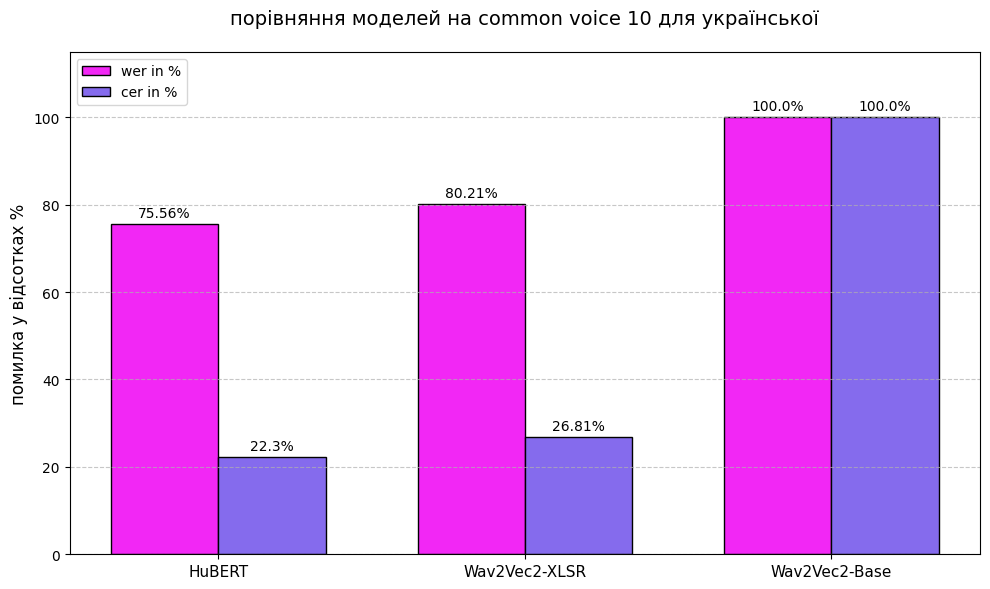

In [26]:
import matplotlib.pyplot as plt
import numpy as np

models = ['HuBERT', 'Wav2Vec2-XLSR', 'Wav2Vec2-Base']
wer = [75.56, 80.21, 100.00]
cer = [22.30, 26.81, 100.00]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, wer, width, label='wer in %', color='#F227F5', edgecolor='black')
rects2 = ax.bar(x + width/2, cer, width, label='cer in %', color='#856BED', edgecolor='black')

ax.set_ylabel('помилка у відсотках %', fontsize=12)
ax.set_title('порівняння моделей на common voice 10 для української', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)
plt.ylim(0, 115)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

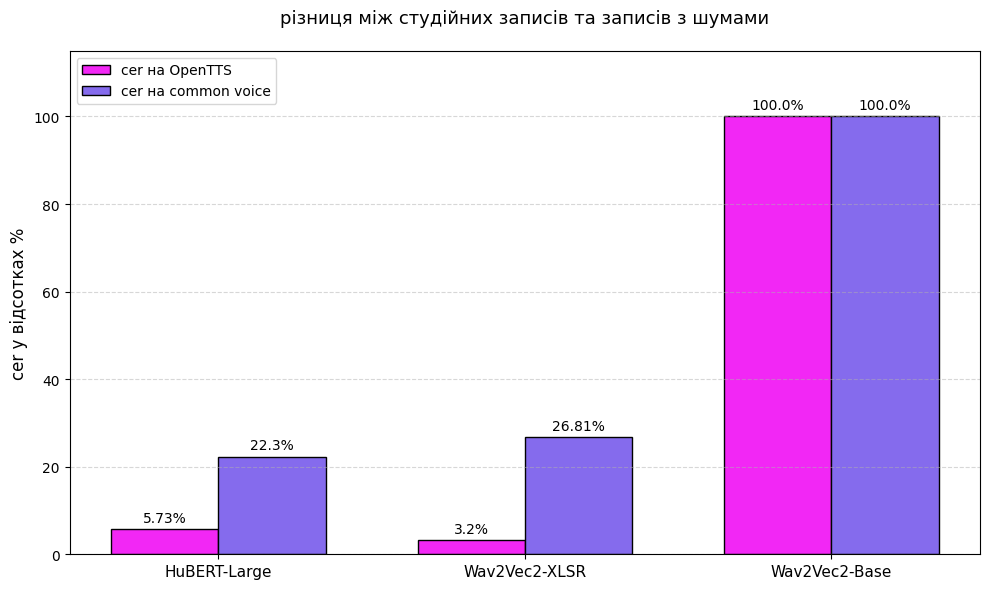

In [27]:
import matplotlib.pyplot as plt
import numpy as np

models = ['HuBERT-Large', 'Wav2Vec2-XLSR', 'Wav2Vec2-Base']
cer_opentts = [5.73, 3.20, 100.00]
cer_cv = [22.30, 26.81, 100.00]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, cer_opentts, width, label='cer на OpenTTS', color='#F227F5', edgecolor='black')
rects2 = ax.bar(x + width/2, cer_cv, width, label='cer на common voice', color='#856BED', edgecolor='black')

ax.set_ylabel('cer у відсотках %', fontsize=12)
ax.set_title('різниця між студійних записів та записів з шумами', fontsize=13, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)
plt.ylim(0, 115)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Завдання 2

1. Покращити якість OpenTTS UK та Common Voice (цільово CV10, fallback CV13 якщо CV10 недоступний).
2. Додати класичні аудіо-фільтри (DSP), без глибоких нейромереж.
3. Перевірити покращення через WER/CER.
4. Додати об'єктивні метрики якості аудіо.

In [28]:
TASK2_CFG = {
    "target_sr": 16000,
    "enable_dc_removal": True,
    "enable_peak_norm": True,
    "peak_target": 0.98,
    "enable_highpass": True,
    "highpass_hz": 70.0,
    "highpass_order": 4,
    "enable_lowpass": False,
    "lowpass_hz": 7600.0,
    "lowpass_order": 6,
    "enable_notch": False,
    "notch_hz": 50.0,
    "notch_q": 30.0,
    "enable_trim": True,
    "trim_db": 35.0,
    "trim_min_ms": 120,
}

def _to_float32(x):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 2:
        x = x.mean(axis=1 if x.shape[1] < x.shape[0] else 0)
    return x

def remove_dc(x):
    return x - np.mean(x)

def peak_normalize(x, target=0.98, eps=1e-8):
    p = np.max(np.abs(x)) + eps
    return (x / p) * target

def apply_highpass(x, sr, cutoff_hz=70.0, order=4):
    sos = butter(order, cutoff_hz, btype="highpass", fs=sr, output="sos")
    return sosfiltfilt(sos, x).astype(np.float32)

def apply_lowpass(x, sr, cutoff_hz=7600.0, order=6):
    sos = butter(order, cutoff_hz, btype="lowpass", fs=sr, output="sos")
    return sosfiltfilt(sos, x).astype(np.float32)

def apply_notch(x, sr, notch_hz=50.0, q=30.0):
    b, a = iirnotch(notch_hz, q, fs=sr)
    return filtfilt(b, a, x).astype(np.float32)


def trim_silence_energy(x, sr, top_db=35.0, min_ms=120):
    # Простий energy-based trimming без DNN
    frame = max(1, int(0.02 * sr))
    hop = max(1, int(0.01 * sr))
    if len(x) < frame:
        return x

    # Frame RMS
    rms = []
    for i in range(0, len(x) - frame + 1, hop):
        seg = x[i:i+frame]
        rms.append(np.sqrt(np.mean(seg**2) + 1e-10))
    rms = np.array(rms)

    rms_db = 20 * np.log10(rms + 1e-10)
    thr = np.max(rms_db) - top_db
    keep = rms_db >= thr
    if not np.any(keep):
        return x

    idx = np.where(keep)[0]
    start = idx[0] * hop
    end = min(len(x), idx[-1] * hop + frame)

    # Мінімальна довжина
    min_len = int((min_ms / 1000.0) * sr)
    if end - start < min_len:
        mid = (start + end) // 2
        start = max(0, mid - min_len // 2)
        end = min(len(x), start + min_len)

    return x[start:end]


def enhance_audio_classical(x, sr, cfg=TASK2_CFG):
    x = _to_float32(x)

    if cfg["enable_dc_removal"]:
        x = remove_dc(x)
    if cfg["enable_highpass"]:
        x = apply_highpass(x, sr, cfg["highpass_hz"], cfg["highpass_order"])
    if cfg["enable_lowpass"]:
        x = apply_lowpass(x, sr, cfg["lowpass_hz"], cfg["lowpass_order"])
    if cfg["enable_notch"]:
        x = apply_notch(x, sr, cfg["notch_hz"], cfg["notch_q"])
    if cfg["enable_trim"]:
        x = trim_silence_energy(x, sr, cfg["trim_db"], cfg["trim_min_ms"])
    if cfg["enable_peak_norm"]:
        x = peak_normalize(x, cfg["peak_target"])

    return np.asarray(x, dtype=np.float32)

In [29]:
def audio_quality_metrics(x, sr):
    x = _to_float32(x)
    eps = 1e-10

    # RMS loudness (dBFS-like)
    rms = np.sqrt(np.mean(x**2) + eps)
    rms_db = 20 * np.log10(rms + eps)

    # Clipping ratio
    clip_ratio = float(np.mean(np.abs(x) >= 0.99))

    # Zero crossing rate
    zcr = float(np.mean(np.abs(np.diff(np.signbit(x)))))

    # Spectral flatness proxy
    f, t, Z = sps.stft(x, fs=sr, nperseg=512, noverlap=256)
    ps = np.abs(Z) ** 2 + eps
    geo = np.exp(np.mean(np.log(ps), axis=0))
    arith = np.mean(ps, axis=0)
    flatness = float(np.mean(geo / (arith + eps)))

    # High-frequency energy ratio (>4kHz)
    hf_mask = f >= 4000
    hf = np.sum(ps[hf_mask])
    all_e = np.sum(ps)
    hf_ratio = float(hf / (all_e + eps))

    # Simple SNR proxy via low energy percentile as noise floor
    frame = max(1, int(0.02 * sr))
    hop = max(1, int(0.01 * sr))
    frame_rms = []
    for i in range(0, max(1, len(x) - frame + 1), hop):
        seg = x[i:i+frame]
        frame_rms.append(np.sqrt(np.mean(seg**2) + eps))
    frame_rms = np.array(frame_rms)
    noise_floor = np.percentile(frame_rms, 15)
    signal_lvl = np.percentile(frame_rms, 85)
    snr_proxy_db = float(20 * np.log10((signal_lvl + eps) / (noise_floor + eps)))

    return {
        "rms_db": float(rms_db),
        "clip_ratio": clip_ratio,
        "zcr": zcr,
        "spectral_flatness": flatness,
        "hf_ratio": hf_ratio,
        "snr_proxy_db": snr_proxy_db,
        "duration_sec": float(len(x) / sr),
    }


def aggregate_quality(ds, n=200, enhanced=False, cfg=TASK2_CFG):
    keys = [
        "rms_db", "clip_ratio", "zcr", "spectral_flatness",
        "hf_ratio", "snr_proxy_db", "duration_sec"
    ]
    acc = {k: [] for k in keys}

    n = min(n, len(ds))
    for i in range(n):
        a = ds[i]["audio"]
        x = _to_float32(a["array"])
        sr = int(a["sampling_rate"])
        if enhanced:
            x = enhance_audio_classical(x, sr, cfg)
        m = audio_quality_metrics(x, sr)
        for k in keys:
            acc[k].append(m[k])

    return {k: float(np.mean(v)) for k, v in acc.items()}

In [30]:
from dataclasses import dataclass
from datasets import Audio, load_dataset
import evaluate
import re
chars_to_remove_regex = r'[,?.!\-;:"“”—_]'


def normalize_text_uk(text: str) -> str:
    text = (text or "").lower()
    text = re.sub(chars_to_remove_regex, "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def maybe_load_opentts_split():
    # Reuse Task 1 variable if it exists
    if "dataset" in globals():
        ds = dataset
        if isinstance(ds, dict) and "train" in ds and "test" in ds:
            return ds

    ds = load_dataset("speech-uk/opentts-mykyta", split="train")
    ds = ds.train_test_split(test_size=0.1, seed=42)
    ds = ds.cast_column("audio", Audio(sampling_rate=16000))
    return ds


def apply_dsp_map(batch, cfg=TASK2_CFG):
    x = _to_float32(batch["audio"]["array"])
    sr = int(batch["audio"]["sampling_rate"])
    y = enhance_audio_classical(x, sr, cfg)
    batch["audio"] = {"array": y, "sampling_rate": sr}
    return batch


def prepare_for_ctc(ds, processor, text_field="transcription"):
    def _prep(batch):
        text = normalize_text_uk(batch[text_field])
        batch["input_values"] = processor(
            batch["audio"]["array"],
            sampling_rate=16000
        ).input_values[0]
        batch["labels"] = processor(text=text).input_ids
        return batch

    return ds.map(_prep)

In [31]:
task2_ds = maybe_load_opentts_split()
print(task2_ds)

DatasetDict({
    train: Dataset({
        features: ['audio', 'duration', 'transcription', 'transcription_stressed'],
        num_rows: 5792
    })
    test: Dataset({
        features: ['audio', 'duration', 'transcription', 'transcription_stressed'],
        num_rows: 644
    })
})


Transcript: що ж ти одступаєш наче од лихого зілля

Old (raw)     -> rms_db: -32.08, clip_ratio: 0.0000, snr_proxy_db: 64.31, duration_sec: 4.979
New (filtered)-> rms_db: -15.47, clip_ratio: 0.0000, snr_proxy_db: 19.53, duration_sec: 3.650


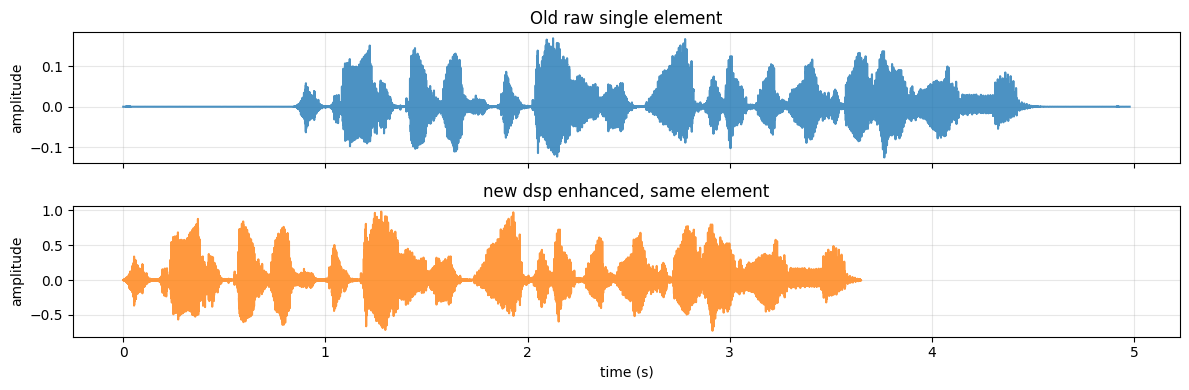

old raw 


new dsp enhanced 


In [32]:
# переглянемо зміни на прикладі одного елемента
idx = 0
split = "train"
row = task2_ds[split][idx]

audio_old = row["audio"]
x_old = _to_float32(audio_old["array"])
sr = int(audio_old["sampling_rate"])
text = row.get("transcription", row.get("sentence", ""))

# New dataset: same sample after DSP pipeline
x_new = enhance_audio_classical(x_old.copy(), sr, TASK2_CFG)

# Metrics for this single sample
m_old = audio_quality_metrics(x_old, sr)
m_new = audio_quality_metrics(x_new, sr)

print("Transcript:", text[:120] + ("..." if len(text) > 120 else ""))
print()
print("Old (raw)     -> rms_db: {:.2f}, clip_ratio: {:.4f}, snr_proxy_db: {:.2f}, duration_sec: {:.3f}".format(
    m_old["rms_db"], m_old["clip_ratio"], m_old["snr_proxy_db"], m_old["duration_sec"]))
print("New (filtered)-> rms_db: {:.2f}, clip_ratio: {:.4f}, snr_proxy_db: {:.2f}, duration_sec: {:.3f}".format(
    m_new["rms_db"], m_new["clip_ratio"], m_new["snr_proxy_db"], m_new["duration_sec"]))

# Waveform comparison
fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
t_old = np.arange(len(x_old)) / sr
t_new = np.arange(len(x_new)) / sr
axes[0].plot(t_old, x_old, color="C0", alpha=0.8)
axes[0].set_ylabel("amplitude")
axes[0].set_title("Old raw single element")
axes[0].grid(True, alpha=0.3)
axes[1].plot(t_new, x_new, color="C1", alpha=0.8)
axes[1].set_ylabel("amplitude")
axes[1].set_xlabel("time (s)")
axes[1].set_title("new dsp enhanced, same element")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Play both (Jupyter/Colab)
try:
    import IPython.display as ipd
    print("old raw ")
    display(ipd.Audio(x_old, rate=sr))
    print("new dsp enhanced ")
    display(ipd.Audio(x_new, rate=sr))
except Exception as e:
    print("audio playback skipped", e)

In [33]:
def filter_by_max_duration(ds, max_sec=12.0):
    def _keep(ex):
        a = ex["audio"]
        x = _to_float32(a["array"])
        sr = int(a["sampling_rate"])
        return (len(x) / sr) <= max_sec

    return ds.filter(_keep)


def prepare_generic_for_ctc(ds, text_col, filtered=False, cfg=TASK2_CFG):
    if filtered:
        ds = ds.map(lambda b: apply_dsp_map(b, cfg))

    def _prep(batch):
        text = normalize_text_uk(batch[text_col])
        batch["input_values"] = processor(batch["audio"]["array"], sampling_rate=16000).input_values[0]
        batch["labels"] = processor(text=text).input_ids
        return batch

    return ds.map(_prep)


def build_task2_trainer(existing_model, train_prepared, eval_prepared, output_dir="./task2_filtered_finetune"):
    data_collator = DataCollatorCTCWithPadding(processor=processor, padding=True)

    args = TrainingArguments(
        output_dir=output_dir,
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        gradient_accumulation_steps=4,
        eval_strategy="steps",
        eval_steps=200,
        save_steps=200,
        logging_steps=50,
        num_train_epochs=1,
        learning_rate=1e-4,
        warmup_steps=50,
        weight_decay=0.005,
        fp16=torch.cuda.is_available(),
        group_by_length=True,
        remove_unused_columns=False,
        save_total_limit=1,
    )

    # Gradient checkpointing
    try:
        existing_model.gradient_checkpointing_enable()
    except Exception:
        pass

    return Trainer(
        model=existing_model,
        args=args,
        train_dataset=train_prepared,
        eval_dataset=eval_prepared,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )


In [34]:
# Save baseline trainer/model from Task 1
baseline_trainer = trainer
baseline_model = baseline_trainer.model

NameError: name 'trainer' is not defined

In [ ]:
ds_train_raw = task2_ds["train"]
ds_test_raw = task2_ds["test"]

# We'll remove long utterances
ds_train_raw = filter_by_max_duration(ds_train_raw, max_sec=12.0)
ds_test_raw = filter_by_max_duration(ds_test_raw, max_sec=12.0)

# Same eval dataset
test_raw_prepared = prepare_generic_for_ctc(ds_test_raw, text_col="transcription", filtered=False)

print("evaluating baseline (task 1 model) on OpenTTS RAW test...")
base_eval = baseline_trainer.evaluate(test_raw_prepared)# Baseline eval

# filetered train and test data
train_filtered_prepared = prepare_generic_for_ctc(ds_train_raw, text_col="transcription", filtered=True)
test_filtered_prepared = prepare_generic_for_ctc(ds_test_raw, text_col="transcription", filtered=True)

In [ ]:

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()

print("finetuning baseline model on FILTERED train only")
filtered_trainer = build_task2_trainer(
    baseline_model,
    train_prepared=train_filtered_prepared,
    eval_prepared=test_raw_prepared,  # keep eval on same test during training
    output_dir="./task2_filtered_finetune",
)
filtered_trainer.train()

# Compare models
print("evaluating filtered trained model on SAME OpenTTS RAW test")
filt_on_raw_eval = filtered_trainer.evaluate(test_raw_prepared)

filt_on_filt_eval = filtered_trainer.evaluate(test_filtered_prepared)

In [ ]:
q_raw = aggregate_quality(ds_test_raw, n=250, enhanced=False)
q_flt = aggregate_quality(ds_test_raw, n=250, enhanced=True)

summary = pd.DataFrame([
    {
        "setting": "baseline_task1_model_on_raw_test",
        "WER": base_eval.get("eval_wer"),
        "CER": base_eval.get("eval_cer"),
    },
    {
        "setting": "filtered_trained_model_on_same_raw_test",
        "WER": filt_on_raw_eval.get("eval_wer"),
        "CER": filt_on_raw_eval.get("eval_cer"),
    },
    {
        "setting": "filtered_trained_model_on_filtered_test_optional",
        "WER": filt_on_filt_eval.get("eval_wer"),
        "CER": filt_on_filt_eval.get("eval_cer"),
    },
])

quality_cmp = pd.DataFrame([
    {"version": "raw", **q_raw},
    {"version": "filtered", **q_flt},
])

print("=== ASR metrics for task 2 ===")
display(summary)

print("=== objective audio quality metrics, OpenTTS test subset ===")
display(quality_cmp)

print("wer same test :", float(summary.loc[1, "WER"] - summary.loc[0, "WER"]))
print("cer same test :", float(summary.loc[1, "CER"] - summary.loc[0, "CER"]))

In [ ]:
cv_base = baseline_trainer.evaluate(cv_test_prepared)
cv_filt = filtered_trainer.evaluate(cv_test_prepared)
print("CV10 baseline task 1:  WER:", cv_base.get("eval_wer"), " CER:", cv_base.get("eval_cer"))
print("CV10 filtered task 2:  WER:", cv_filt.get("eval_wer"), " CER:", cv_filt.get("eval_cer"))

In [ ]:
print("клікай сюди щоб сесія не закрилась")